In [ ]:
import os
import json
from sentence_transformers import SentenceTransformer

In [2]:
# --------------------------------
# CONFIG
# --------------------------------
MINISTRY_DIR = "../data/ministry_profiles"
OUTPUT_FILE = "../data/embeddings/ministry_embeddings.json"

MODEL_NAME = "all-MiniLM-L6-v2"
CACHE_DIR = "../models"

In [3]:
# --------------------------------
# Load ministry texts
# --------------------------------
def load_ministry_texts(directory):

    ministries = {}

    for file in os.listdir(directory):
        if file.endswith(".txt"):

            path = os.path.join(directory, file)

            with open(path, "r", encoding="utf-8") as f:
                text = f.read()

            name = file.replace(".txt", "")
            ministries[name] = text

    return ministries

In [4]:
import re

def clean_text(text):

    # remove bullet characters
    text = text.replace("\uf0b7", " ")

    # remove numbering like "1." "2."
    text = re.sub(r"\n?\d+\.\s*", " ", text)

    # replace newlines with space
    text = text.replace("\n", " ")

    # remove multiple spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [5]:
# --------------------------------
# Build embeddings
# --------------------------------
def build_ministry_embeddings(ministries):

    model = SentenceTransformer(MODEL_NAME, cache_folder=CACHE_DIR)

    ministry_vectors = {}

    for name, text in ministries.items():

        cleaned = clean_text(text)

        embedding = model.encode(cleaned)

        ministry_vectors[name] = embedding.tolist()

    return ministry_vectors

In [6]:
# --------------------------------
# Save embeddings
# --------------------------------
def save_embeddings(vectors, output_file):

    os.makedirs(os.path.dirname(output_file), exist_ok=True)

    with open(output_file, "w") as f:
        json.dump(vectors, f)

    print("Embeddings saved to:", output_file)

In [7]:
# --------------------------------
# MAIN
# --------------------------------
# if __name__ == "__main__":

ministries = load_ministry_texts(MINISTRY_DIR)

print("Loaded ministries:", len(ministries))

Loaded ministries: 53


In [8]:
ministry_vectors = build_ministry_embeddings(ministries)

save_embeddings(ministry_vectors, OUTPUT_FILE)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embeddings saved to: ../data/embeddings/ministry_embeddings.json


In [12]:
len(ministries), len(ministry_vectors), len(ministry_vectors["Ministry_of_AYUSH_MoA_"])

(53, 53, 384)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [14]:
data = ministry_vectors.copy()

names = list(data.keys())
vectors = np.array(list(data.values()))

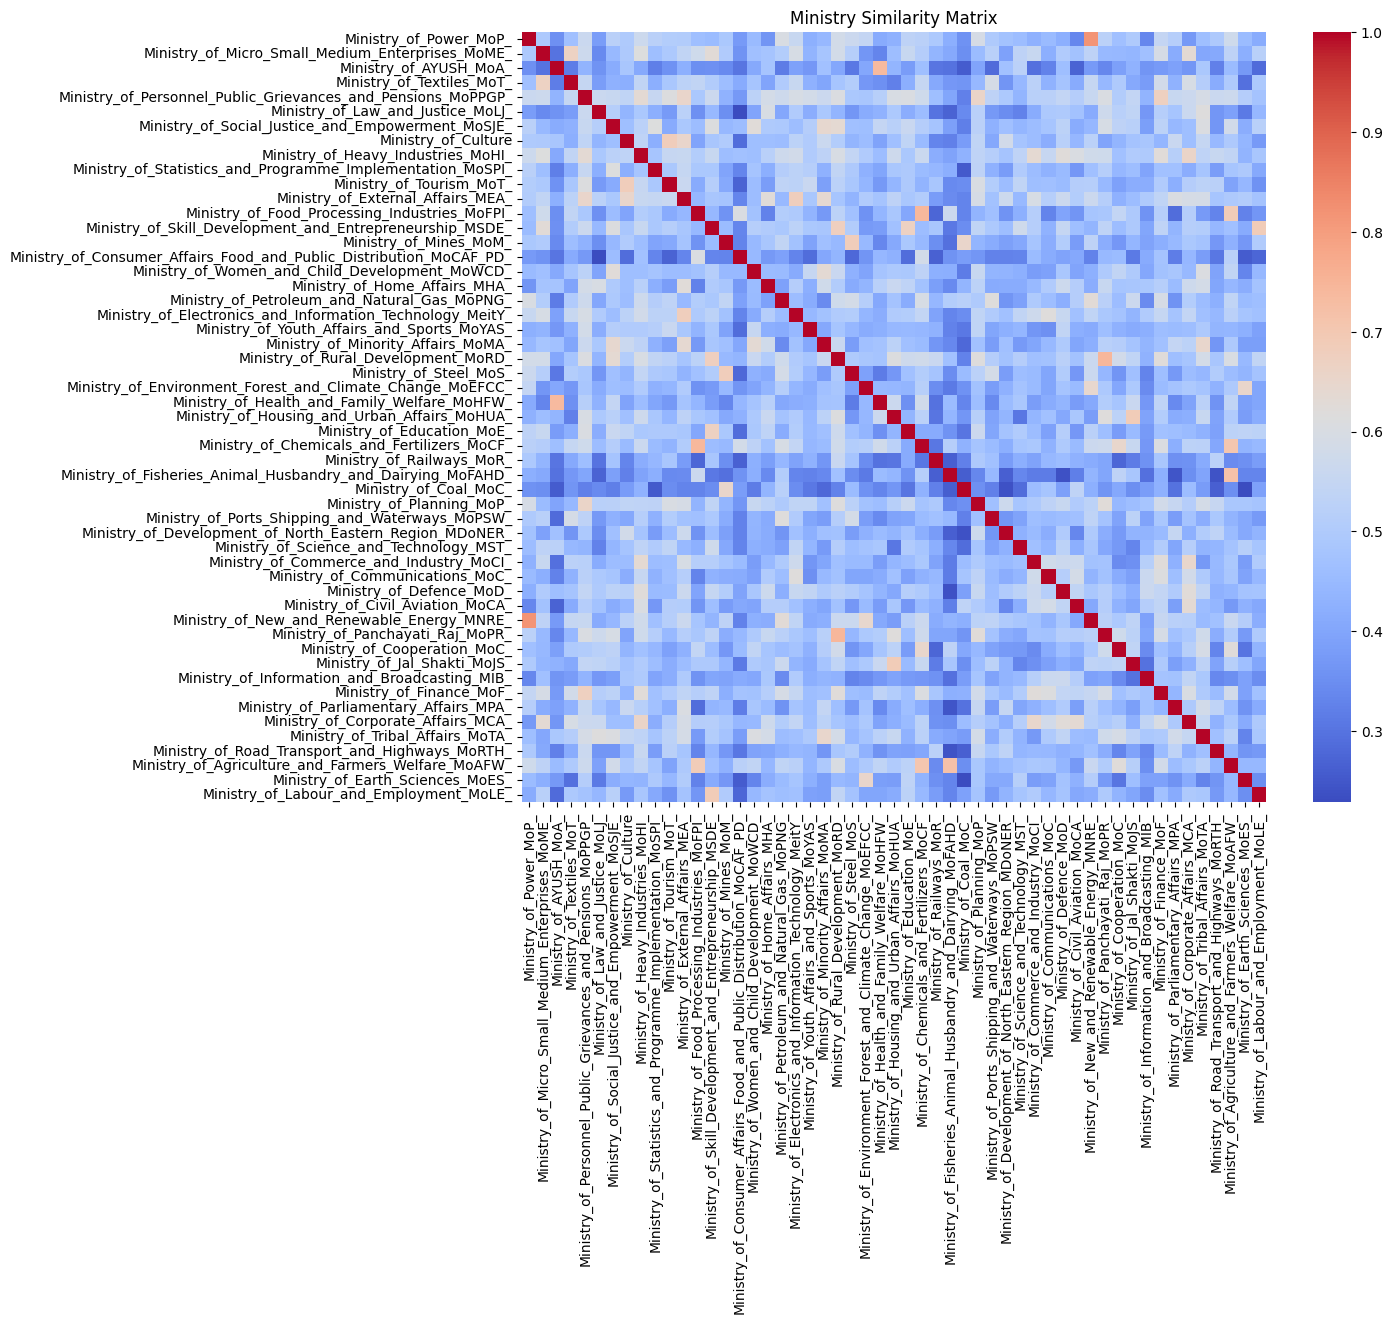

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns

sim = cosine_similarity(vectors)

plt.figure(figsize=(12,10))
sns.heatmap(sim, xticklabels=names, yticklabels=names, cmap="coolwarm")
plt.title("Ministry Similarity Matrix")
plt.show()

In [28]:
# get only last _..._ part of the name for better visualization
names = [name.split("_")[-2] if name.split("_")[-1] == "" else name.split("_")[-1] for name in names]

In [30]:

# reduce dimension
tsne = TSNE(n_components=2, random_state=42, perplexity=5)
reduced = tsne.fit_transform(vectors)


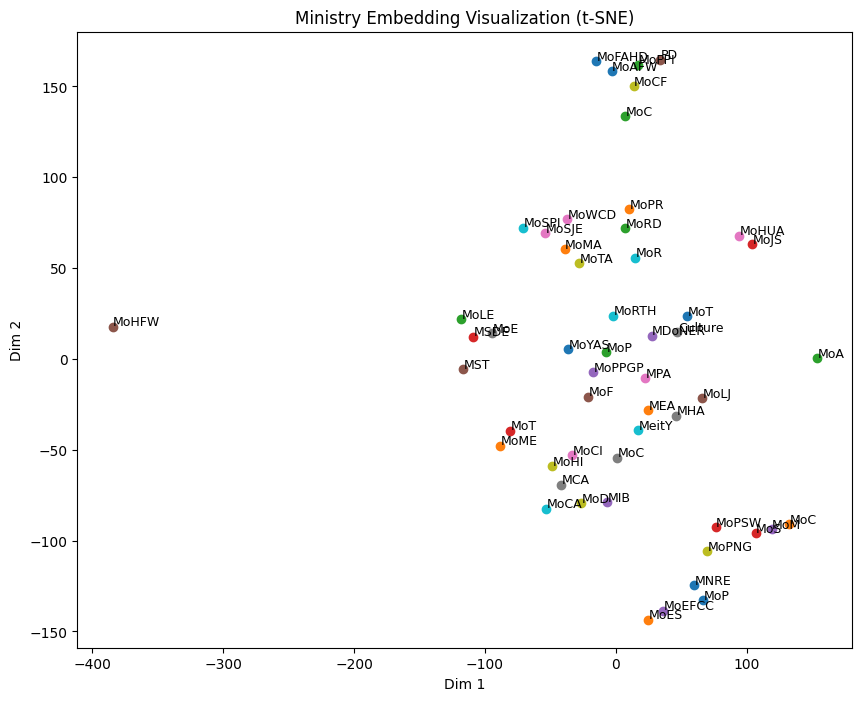

In [31]:

# plot
plt.figure(figsize=(10,8))

for i, name in enumerate(names):
    x, y = reduced[i]
    plt.scatter(x, y)
    plt.text(x+0.5, y+0.5, name, fontsize=9)

plt.title("Ministry Embedding Visualization (t-SNE)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()

In [20]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

Explained variance: [0.07342393 0.06757181 0.05964894]


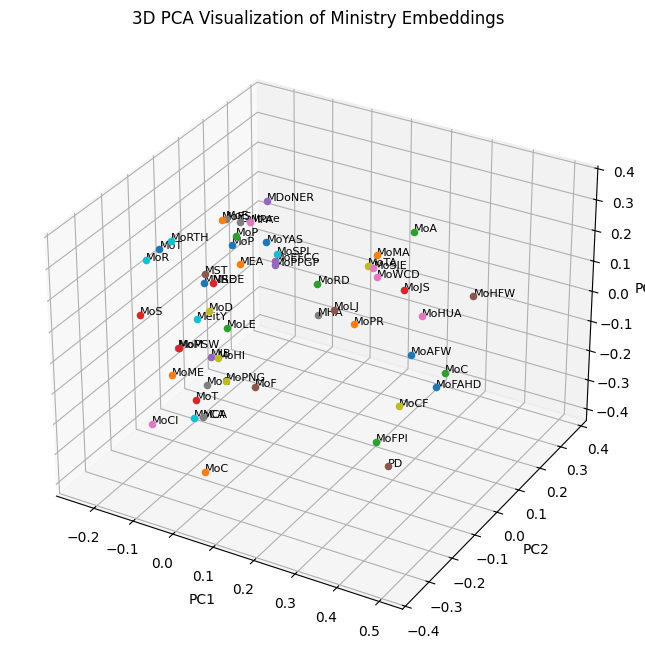

In [32]:
# --------------------------------
# PCA -> 3 components
# --------------------------------
pca = PCA(n_components=3)
reduced = pca.fit_transform(vectors)

print("Explained variance:", pca.explained_variance_ratio_)

# --------------------------------
# 3D Plot
# --------------------------------
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

for i, name in enumerate(names):
    x, y, z = reduced[i]

    ax.scatter(x, y, z)
    ax.text(x, y, z, name, fontsize=8)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

ax.set_title("3D PCA Visualization of Ministry Embeddings")

plt.show()